In [ ]:
!pip install anndata scanpy squidpy leidenalg
import pandas as pd

import matplotlib.pyplot as plt

import anndata as ad
import scanpy as sc
import squidpy as sq

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

# load the pre-processed dataset
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

In [ ]:
#this dataset is a smaller crop of the whole brain section
#visualizing the cluster annotation in the spatial context

sq.pl.spatial_scatter(adata, color="cluster")

In [ ]:
#The fluorescence image provided with this dataset has three channels: DAPI (specific to DNA), anti-NEUN (specific to neurons), anti-GFAP (specific to Glial cells).

img.show(channelwise=True)

In [ ]:
sq.im.calculate_image_features(adata=adata, img=img)

In [ ]:
# extracting image features

import numpy as np

import seaborn as sns

import squidpy as sq

# get spatial dataset including high-resolution tissue image
img = sq.datasets.visium_hne_image_crop()
adata = sq.datasets.visium_hne_adata_crop()

In [ ]:
np.set_printoptions(threshold=10)
print(img)
print(adata.obsm["spatial"])

sq.pl.spatial_scatter(adata, outline=True, size=0.3)

In [ ]:
sq.im.calculate_image_features(
    adata, img, features="summary", key_added="features", show_progress_bar=False
)

# show the calculated features
adata.obsm["features"].head()

In [ ]:
# median values of all channels
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "features"),
    color=[
        "summary_ch-0_quantile-0.5",
        "summary_ch-0_quantile-0.5",
        "summary_ch-2_quantile-0.5",
    ],
)

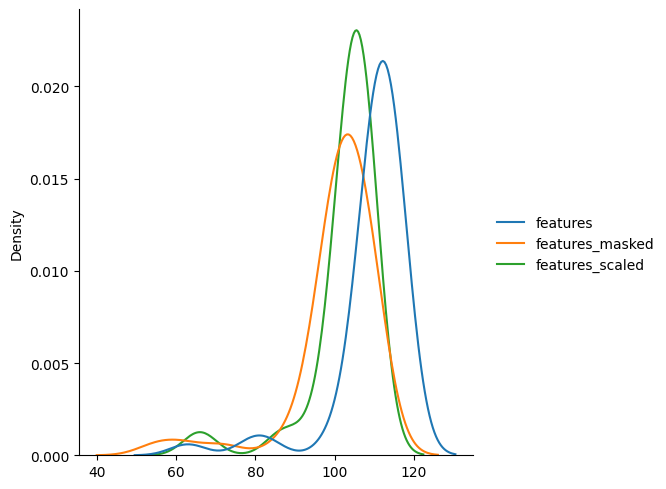

In [ ]:
# specify crop appearence

adata_sml = adata[:50].copy()

# calculate default features
sq.im.calculate_image_features(
    adata_sml,
    img,
    features=["summary", "texture", "histogram"],
    key_added="features",
    show_progress_bar=False,
)
# calculate features with masking
sq.im.calculate_image_features(
    adata_sml,
    img,
    features=["summary", "texture", "histogram"],
    key_added="features_masked",
    mask_circle=True,
    show_progress_bar=False,
)
# calculate features with scaling and larger context
sq.im.calculate_image_features(
    adata_sml,
    img,
    features=["summary", "texture", "histogram"],
    key_added="features_scaled",
    mask_circle=True,
    spot_scale=2,
    scale=0.5,
    show_progress_bar=False,
)

# plot distribution of median for different cropping options
_ = sns.displot(
    {
        "features": adata_sml.obsm["features"]["summary_ch-0_quantile-0.5"],
        "features_masked": adata_sml.obsm["features_masked"][
            "summary_ch-0_quantile-0.5"
        ],
        "features_scaled": adata_sml.obsm["features_scaled"][
            "summary_ch-0_quantile-0.5"
        ],
    },
    kind="kde",
)

In [ ]:
# Parallelization

sq.im.calculate_image_features(
    adata,
    img,
    features="summary",
    key_added="features",
    n_jobs=4,
    show_progress_bar=False,
)

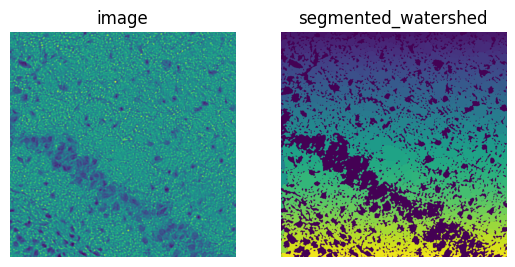

In [ ]:
# image segmentation

sq.im.process(
    img=img,
    layer="image",
    method="smooth",
)

sq.im.segment(img=img, layer="image_smooth", method="watershed", channel=0, chunks=1000)

# plot the resulting segmentation
fig, ax = plt.subplots(1, 2)
img_crop = img.crop_corner(2000, 2000, size=500)
img_crop.show(layer="image", channel=0, ax=ax[0])
img_crop.show(
    layer="segmented_watershed",
    channel=0,
    ax=ax[1],
)

In [ ]:
# extract segmentation features

import matplotlib.pyplot as plt

import squidpy as sq

In [ ]:
# First, let’s load the fluorescence Visium dataset
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

In [ ]:
# before calculating features we need to calculate segmentation first

sq.im.segment(
    img=img,
    layer="image",
    layer_added="segmented_watershed",
    method="watershed",
    channel=0,
)

In [ ]:
# now calculate segmentation features

sq.im.calculate_image_features(
    adata,
    img,
    layer="image",
    features="segmentation",
    key_added="segmentation_features",
    features_kwargs={
        "segmentation": {
            "label_layer": "segmented_watershed",
            "props": ["label", "area", "mean_intensity"],
            "channels": [1, 2],
        }
    },
    mask_circle=True,
)

In [ ]:
adata.obsm["segmentation_features"].head()

In [ ]:
#Use squidpy.pl.extract to plot the texture features on the tissue image

# show all channels (using low-res image contained in adata to save memory)
fig, axes = plt.subplots(1, 3, figsize=(8, 4))
for i, ax in enumerate(axes):
    ax.imshow(
        adata.uns["spatial"]["V1_Adult_Mouse_Brain_Coronal_Section_2"]["images"][
            "hires"
        ][:, :, i]
    )
    ax.set_title(f"ch{i}")

# plot segmentation features
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "segmentation_features"),
    color=[
        "segmentation_label",
        "segmentation_area_mean",
        "segmentation_ch-1_mean_intensity_mean",
        "segmentation_ch-2_mean_intensity_mean",
    ],
    img_cmap="gray",
    ncols=2,
)

In [ ]:
import squidpy as sq
# First, let’s load the fluorescence Visium dataset
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()
# before calculating features we need to calculate segmentation first
sq.im.segment(
    img=img,
    layer="image",
    layer_added="segmented_watershed",
    method="watershed",
    channel=0,
)
# define image layer to use for segmentation
features_kwargs = {"segmentation": {"label_layer": "segmented_watershed"}}
# calculate segmentation features
sq.im.calculate_image_features(
    adata,
    img,
    features="segmentation",
    layer="image",
    key_added="features_segmentation",
    n_jobs=1,
    features_kwargs=features_kwargs,
)
# plot results and compare with gene-space clustering
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "features_segmentation"),
    color=[
        "segmentation_label",
        "cluster",
        "segmentation_ch-0_mean_intensity_mean",
        "segmentation_ch-1_mean_intensity_mean",
    ],
    frameon=False,
    ncols=2,
)

In [ ]:
# Extract summary features

import squidpy as sq


In [ ]:
#  load the fluorescence Visium dataset
# get spatial dataset including hires tissue image
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

In [ ]:
# calculate summary features and save in key "summary_features"
sq.im.calculate_image_features(
    adata,
    img,
    features="summary",
    features_kwargs={
        "summary": {
            "quantiles": [0.1],
            "channels": [0, 1],
        }
    },
    key_added="summary_features",
    mask_circle=True,
    show_progress_bar=False,
)

In [ ]:
adata.obsm["summary_features"].head()

In [ ]:
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "summary_features"),
    color=[None, "summary_ch-0_mean", "summary_ch-1_mean"],
    img_cmap="gray",
)

In [ ]:
# extract histogram features
import squidpy as sq

In [ ]:
# get spatial dataset including high-resolution tissue image
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

# calculate histogram features and save in key "histogram_features"
sq.im.calculate_image_features(
    adata,
    img,
    features="histogram",
    features_kwargs={"histogram": {"bins": 3, "channels": [0, 1]}},
    key_added="histogram_features",
)

In [ ]:
adata.obsm["histogram_features"].head()

In [ ]:
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "histogram_features"),
    color=[
        None,
        "histogram_ch-0_bin-0",
        "histogram_ch-0_bin-1",
        "histogram_ch-0_bin-2",
    ],
    img_cmap="gray",
)

In [ ]:
# extract texture features
import squidpy as sq

In [ ]:
# get spatial dataset including high-resolution tissue image
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

# calculate texture features and save in key "texture_features"
sq.im.calculate_image_features(
    adata,
    img,
    features="texture",
    key_added="texture_features",
    spot_scale=2,
    show_progress_bar=False,
)

In [ ]:
adata.obsm["texture_features"].head()

In [ ]:
sq.pl.spatial_scatter(
    sq.pl.extract(adata, "texture_features"),
    color=[
        None,
        "texture_ch-0_contrast_dist-1_angle-0.00",
        "texture_ch-1_contrast_dist-1_angle-0.00",
    ],
    img_cmap="gray",
)

In [ ]:
import pandas as pd
import anndata as ad

# define different feature calculation combinations
params = {
    # all features, corresponding only to tissue underneath spot
    "features_orig": {
        "features": ["summary", "texture", "histogram"],
        "scale": 1.0,
        "mask_circle": True,
    },
    # summary and histogram features with a bit more context, original resolution
    "features_context": {"features": ["summary", "histogram"], "scale": 1.0},
    # summary and histogram features with more context and at lower resolution
    "features_lowres": {"features": ["summary", "histogram"], "scale": 0.25},
}

for feature_name, cur_params in params.items():
    # features will be saved in `adata.obsm[feature_name]`
    sq.im.calculate_image_features(
        adata, img, layer="image", key_added=feature_name, n_jobs=1, **cur_params
    )

# combine features in one dataframe
adata.obsm["features"] = pd.concat(
    [adata.obsm[f] for f in params.keys()], axis="columns"
)

# make sure that we have no duplicated feature names in the combined table
adata.obsm["features"].columns = ad.utils.make_index_unique(
    adata.obsm["features"].columns
)


In [ ]:
# we first define a helper function to cluster features
def cluster_features(features: pd.DataFrame, like=None):
    """
    Calculate leiden clustering of features.

    Specify filter of features using `like`.
    """
    # filter features
    if like is not None:
        features = features.filter(like=like)
    # create temporary adata to calculate the clustering
    adata = ad.AnnData(features)
    # important - feature values are not scaled, so need to scale them before PCA
    sc.pp.scale(adata)
    # calculate leiden clustering
    sc.pp.pca(adata, n_comps=min(10, features.shape[1] - 1))
    sc.pp.neighbors(adata)
    sc.tl.leiden(adata)

    return adata.obs["leiden"]

In [ ]:
adata.obs["features_summary_cluster"] = cluster_features(
    adata.obsm["features"], like="summary"
)
adata.obs["features_histogram_cluster"] = cluster_features(
    adata.obsm["features"], like="histogram"
)
adata.obs["features_texture_cluster"] = cluster_features(
    adata.obsm["features"], like="texture"
)

sc.set_figure_params(facecolor="white", figsize=(8, 8))
sq.pl.spatial_scatter(
    adata,
    color=[
        "features_summary_cluster",
        "features_histogram_cluster",
        "features_texture_cluster",
        "cluster",
    ],
    ncols=3,
)